# Epic of Sun - Desafio 1
Testing the trained model.
***

This jupyter notebook tests the UNet trained for sugarcane identification from satellite images.

It is divided in 4 parts:
* Loading libraries and test data
* Preparing the test data
* Build the model form saved data
* Evaluate the model

***

## Loading libraries and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import geopandas as gpd
import rasterio
from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import sklearn as sk

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

In [ ]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "test"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv" )

print(patch_index.head())
print(len(patch_index))

        scene  patch  row  col                 image_file  \
0  scene_test      0    0    0  scene_test_patch00000.npy   
1  scene_test      1    0   64  scene_test_patch00001.npy   
2  scene_test      2    0  128  scene_test_patch00002.npy   
3  scene_test      3    0  192  scene_test_patch00003.npy   
4  scene_test      4    0  256  scene_test_patch00004.npy   

                   mask_file  
0  scene_test_patch00000.npy  
1  scene_test_patch00001.npy  
2  scene_test_patch00002.npy  
3  scene_test_patch00003.npy  
4  scene_test_patch00004.npy  
5001


## Preparing the data

In [6]:
# Random split for one Sentinel scene
# With more scenes, split by scene, not by patch.

# Everything goes to the test set as we are testing the results of the model on a new scene. The model was trained on a different scene.
test_df = sk.utils.resample(patch_index, random_state=42)

In [7]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [8]:
# Function to load the patches individually

def load_dataset(df, base_path, compute_indices=True):
    """
    Loads .npy patches listed in a DataFrame into memory as NumPy arrays.
    
    Parameters:
        df (pd.DataFrame): Dataframe slice (train, val, or test) containing patch paths.
        base_path (Path): Root project directory to resolve relative file paths.
    """
    X = []
    Y = []

    for _, row in df.iterrows():
        # Resolve path relative to base_path (or remove base_path / if paths in CSV are absolute)
        x_path = base_path / "images" / row["image_file"]
        y_path = base_path / "masks" / row["mask_file"]

        x = np.load(x_path).astype(np.float32)
        y = np.load(y_path).astype(np.float32)

        X.append(x)
        Y.append(y)

    # Stack into 4D arrays: (N, H, W, C)
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

	# Append spectral indices if requested
    if compute_indices:
        X = add_spectral_indices(X)

    return X, Y

In [9]:
# Load the datasets

# Pass base_path so Path resolution works smoothly across notebooks
X_test, y_test = load_dataset(test_df, base_path / "data" / "test", compute_indices=True)

In [10]:
# Print the shapes and data types of the datasets
# Shape will now be (N, 128, 128, 7) -> [Blue, Green, Red, NIR, NDVI, NDWI, EVI]
print("\nTest set:")
print(X_test.shape)
print(y_test.shape)

print(X_test.dtype)
print(y_test.dtype)

print(np.unique(y_test))


Test set:
(5001, 128, 128, 7)
(5001, 128, 128)
float32
float32
[0. 1.]


In [11]:
# Print the first row of the patch index
print(patch_index.iloc[0])

scene                        scene_test
patch                                 0
row                                   0
col                                   0
image_file    scene_test_patch00000.npy
mask_file     scene_test_patch00000.npy
Name: 0, dtype: object


## Build the Model

In [12]:
# You can just load the model if already trained and not run the random search and best model again

history_dict = None  # Initialize history_dict to None

model_path = base_path / "models" / "unet_sugarcane.keras"
history_path = base_path / "models" / "training_history.json"

if model_path.exists():
	try:
		# Pass str(model_path) to ensure compatibility
		model = load_model(str(model_path), compile=False)
		print("Successfully loaded saved model.")
	except Exception as e:
		print(f"File exists, but load_model failed with error:\n{e}")
else:
	print("File does not exist at the specified path. Check your working directory or base_path.")

if history_path.exists():
	try:
		with open(str(history_path), 'r') as f:
			history_dict = json.load(f)
		print("Successfully loaded saved training history.")
	except Exception as e:
		print(f"File exists, but loading training history failed with error:\n{e}")
else:
	print("Training history file does not exist at the specified path. Check your working directory or base_path.")

I0000 00:00:1785702349.405994  163554 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Successfully loaded saved model.
Successfully loaded saved training history.


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy_test.png'


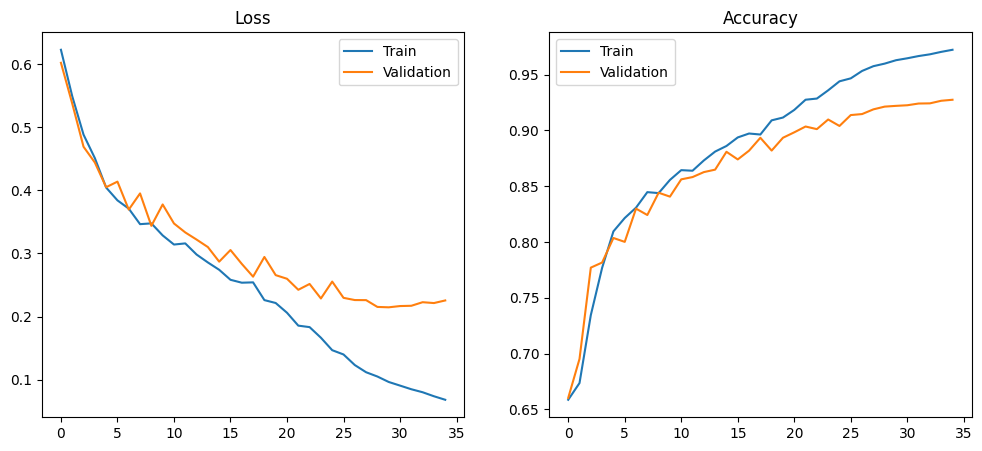

In [13]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "loss_accuracy_test.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

In [14]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

I0000 00:00:1785702356.198888  164890 service.cc:148] XLA service 0x7a3a4800ce80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785702356.214414  164890 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-02 17:25:56.229088: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785702356.606718  164890 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1785702362.104011  164890 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


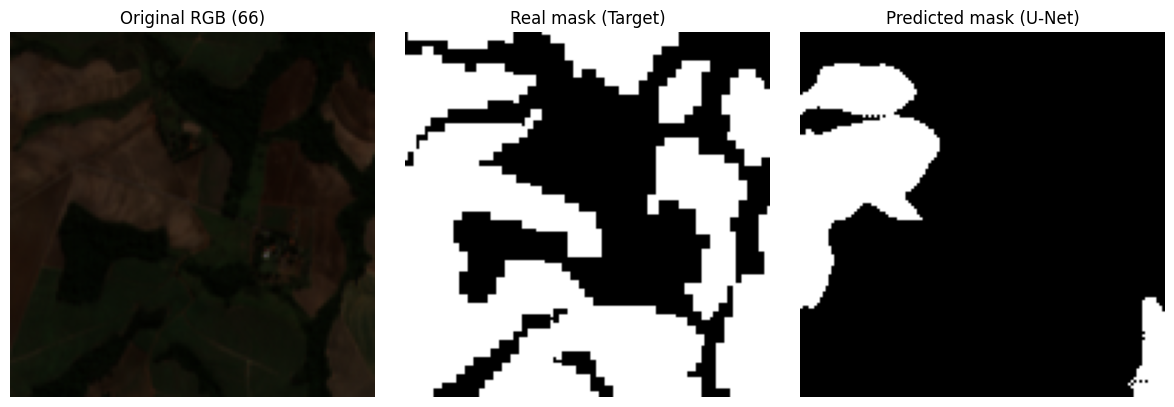

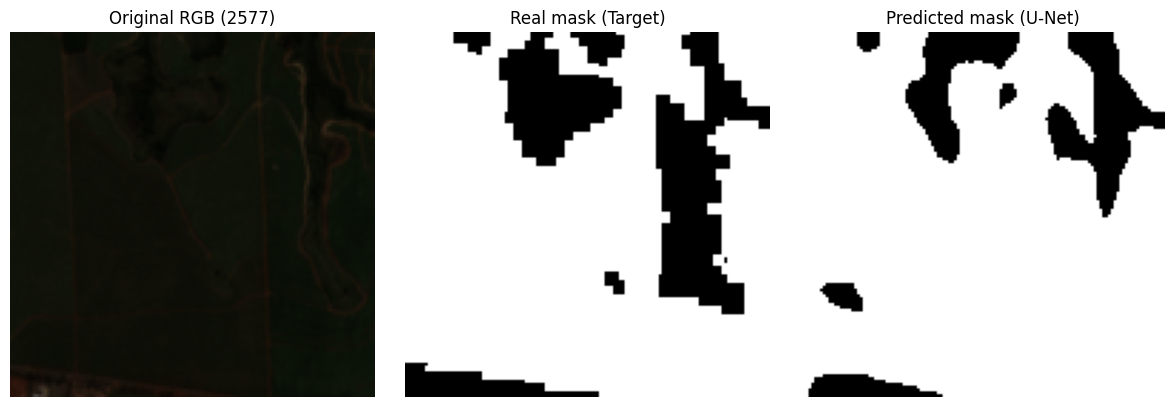

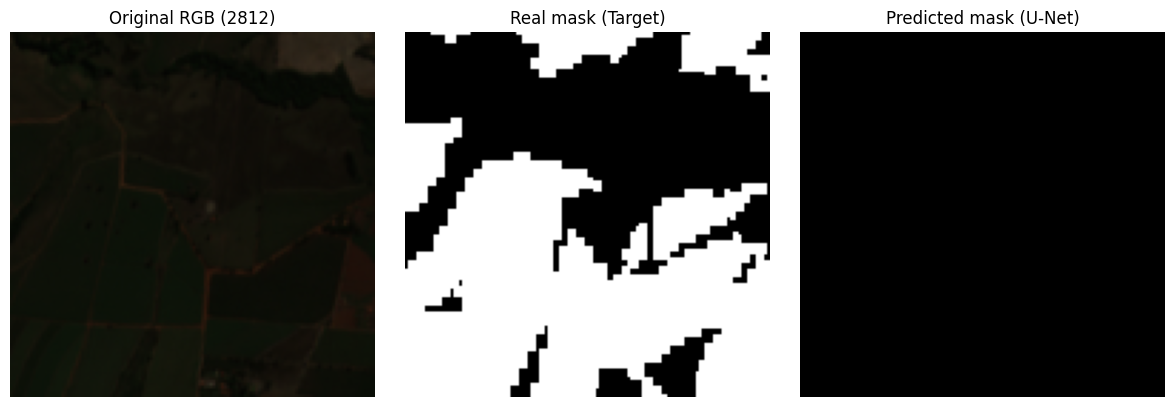

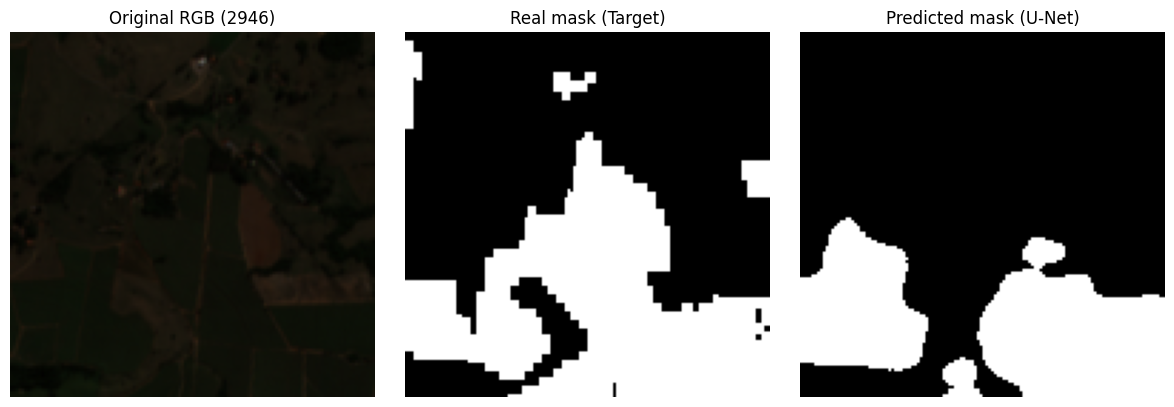

In [15]:
# Make all the predictions on the test set and visualize 4 random results

max_plots = 4  # Number of images to visualize

all_predictions = []  # List to accumulate all predictions

j = 0 # Counter for saved figure filenames

i_numbers = random.sample(range(len(X_test)), k=max_plots) # Randomly select indices for visualization

for i in range(len(X_test)):
    # 1. Extract single image and make prediction
    single_img = X_test[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove batch dimension
    pred_squeezed = pred[0]
    all_predictions.append(pred_squeezed)
    
    # 2. VISUALIZATION SETUP (Only for the first X images)
    if i in i_numbers:
        binary_pred = pred_squeezed > 0.5
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        
        # Extract RGB channels [Red=2, Green=1, Blue=0]
        # Clip to [0, 1] bounds so matplotlib displays colors accurately
        rgb_img = np.clip(X_test[i][::1, ::1, [2, 1, 0]], 0, 1).copy()
        #rgb = rgb[:, :, [2, 1, 0]] # If the bands are in BGR order, you can use this line instead to convert to RGB
        rgb = stretch_rgb(rgb_img)

        ax[0].imshow(rgb_img)
        ax[0].set_title(f"Original RGB ({i})")
        ax[0].axis('off')
        
        ax[1].imshow(y_test[i].squeeze(), cmap='gray')
        ax[1].set_title("Real mask (Target)")
        ax[1].axis('off')
        
        ax[2].imshow(binary_pred.squeeze(), cmap='gray')
        ax[2].set_title("Predicted mask (U-Net)")
        ax[2].axis('off')
        
        file_path = base_path / "figures" / f"unet_sugarcane_results_{j}_test.png"
        file_path.parent.mkdir(parents=True, exist_ok=True)
        j += 1
        
        plt.tight_layout()
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        plt.show()

In [16]:
# Metrics Calculation

# 1. Convert all collected predictions into a matching NumPy array
# Shape will become (N, H, W, C) matching y_train
y_pred_all = np.array(all_predictions)

# 2. Transform both entire sets into binary integers
y_pred_bin = (y_pred_all > 0.5).astype(int)
y_true_bin = y_test.astype(int)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_test.astype(float).ravel()
y_pred_float = y_pred_all.astype(float).ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the test dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Intersection over Union (IoU) for the sugarcane class
# Instantiate the metric object
# target_class_ids=[1] isolates the sugarcane class, ignoring background pixels
iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

# Update the metric state with true masks and predicted probabilities
iou_metric.update_state(y_true_flat, y_pred_flat)

# Extract and print the final result
final_iou = iou_metric.result().numpy()
print(f"IoU: {final_iou:.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the test dataset:
Precision: 0.7145
Recall: 0.5477
F1-Score: 0.6200
ROC AUC Score: 0.7322
IoU: 0.4493

Confusion Matrix:
[[54410002  4942444]
 [10215736 12368202]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88  59352446
           1       0.71      0.55      0.62  22583938

    accuracy                           0.82  81936384
   macro avg       0.78      0.73      0.75  81936384
weighted avg       0.81      0.82      0.81  81936384



/tmp/ipykernel_163554/4176099388.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_163554/4176099388.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, dpi=300, bbox_inches='tight')



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results_test.png'


/home/fdesmello/miniconda3/envs/sugarcane/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


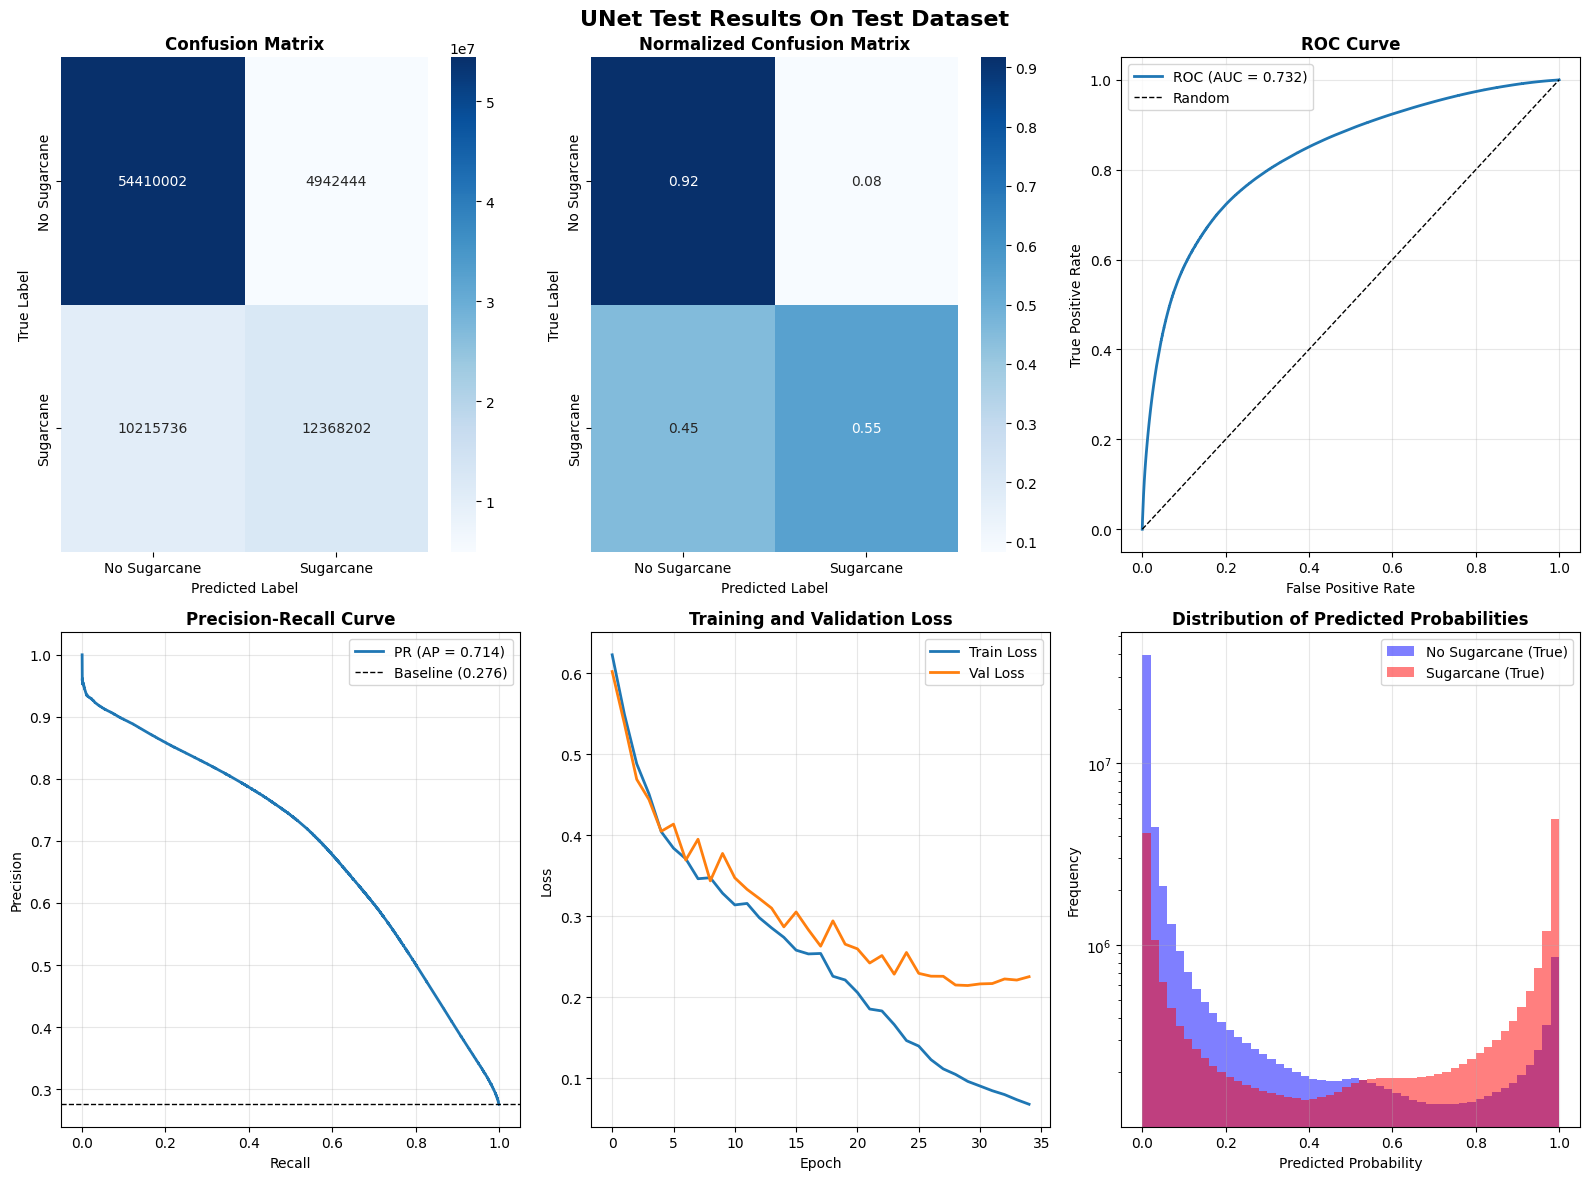

In [17]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results On Test Dataset', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
ax5 = plt.subplot(2, 3, 5)
ax5.plot(history_dict["loss"], label='Train Loss', linewidth=2)
ax5.plot(history_dict["val_loss"], label='Val Loss', linewidth=2)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Loss')
ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results_test.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()